In [1]:
import os
import sys
import json
import matplotlib

import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import seaborn as sns
import sklearn.metrics
import tacco as tc
import time 
import tracemalloc 



In [ ]:

# -------------------------------------------------------------------
# Set this to the directory containing your input .h5ad files.
# -------------------------------------------------------------------

DATA_DIR = os.environ.get("XENIUM_DATA_DIR", "path/to/data")


# -------------------------------------------------------------------
# Load samples
# -------------------------------------------------------------------

sample_files = {
    "NC1": "sample_NC1.h5ad",
    "C2": "sample_C2.h5ad",
    "C4": "sample_C4.h5ad",
    "C3": "sample_C3.h5ad",
    "NC2": "sample_NC2.h5ad",
    "NC3": "sample_NC3.h5ad",
    "C1": "sample_C1.h5ad",
    "NC4": "sample_NC4.h5ad",
    "S_C5": "sample_S_C5.h5ad",
    "S_NC13": "sample_S_NC13.h5ad",
    "S_C6": "sample_S_C6.h5ad",
    "S_C7": "sample_S_C7.h5ad",
    "NC8": "sample_NC8.h5ad",
    "NC5": "sample_NC5.h5ad",
    "S_C10": "sample_S_C10.h5ad",
    "S_C9": "sample_S_C9.h5ad",
    "S_C8": "sample_S_C8.h5ad",
}


# Load all AnnData objects
adatas = {
    sample: sc.read(os.path.join(DATA_DIR, filename))
    for sample, filename in sample_files.items()
}


# -------------------------------------------------------------------
# Concatenate samples
# -------------------------------------------------------------------

combined = ad.concat(
    list(adatas.values()),
    axis=0,
    join="outer",
    label="sample",
    keys=list(adatas.keys()),
)


# -------------------------------------------------------------------
# Assign experimental conditions
# -------------------------------------------------------------------

condition_map = {
    "NC1": "Non-Cytopenic",
    "NC2": "Non-Cytopenic",
    "NC3": "Non-Cytopenic",
    "NC4": "Non-Cytopenic",
    "NC5": "Non-Cytopenic",
    "NC8": "Non-Cytopenic",
    "S_NC13": "Non-Cytopenic",

    "C1": "Cytopenic",
    "C2": "Cytopenic",
    "C3": "Cytopenic",
    "C4": "Cytopenic",
    "S_C5": "Cytopenic",
    "S_C6": "Cytopenic",
    "S_C7": "Cytopenic",
    "S_C8": "Cytopenic",
    "S_C9": "Cytopenic",
    "S_C10": "Cytopenic",
}


combined.obs["condition"] = combined.obs["sample"].map(condition_map)


# -------------------------------------------------------------------
# Standardize cell-type annotation
# -------------------------------------------------------------------

combined.obs["Tacco_pred_cell_type"] = (
    combined.obs["Tacco_pred_cell_type"]
    .replace("Myeloma.mesenchymal", "Mesenchymal")
)


/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/var/folders/8y/pr3hwpm17132d6nyjkjsrys00000gq/T/ipykernel_30971/785079167.py:54: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  combined.obs['Tacco_pred_cell_type'] = combined.obs['Tacco_pred_cell_type'].replace('Myeloma.mesenchymal', 'Mesenchymal')


In [6]:
from scipy.spatial.distance import cdist

def create_detailed_distance_data():
    """Create detailed distance data for each HSC to each cell type, by patient and condition."""
    
    detailed_data = []
    all_cell_types = [ct for ct in combined.obs['Tacco_pred_cell_type'].unique() if ct != 'HSC']
    
    for sample in combined.obs['sample'].unique():
        
        sample_data = combined[combined.obs['sample'] == sample]
        condition = condition_map[sample]
        
        # Get HSCs for this patient
        hsc_cells = sample_data[sample_data.obs['Tacco_pred_cell_type'] == 'HSC']
        if len(hsc_cells) == 0:
            continue
            
        hsc_coords = hsc_cells.obsm['spatial']
        
        # For each cell type, calculate distances
        for target_celltype in all_cell_types:
            target_cells = sample_data[sample_data.obs['Tacco_pred_cell_type'] == target_celltype]
            
            if len(target_cells) > 0:
                target_coords = target_cells.obsm['spatial']
                
                # Calculate distances from each HSC to nearest target cell
                distances = cdist(hsc_coords, target_coords)
                min_distances = np.min(distances, axis=1)
                
                # Store each distance measurement
                for dist in min_distances:
                    detailed_data.append({
                        'Patient': sample,
                        'Condition': condition,
                        'Cell_Type': target_celltype,
                        'Distance': dist
                    })
    
    return pd.DataFrame(detailed_data)

# Create the detailed dataset
detailed_distances = create_detailed_distance_data()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.patheffects as pe

# Calculate mean distances per patient per cell type
def calculate_patient_level_means():
    """Calculate mean distance from HSCs to each cell type for each patient."""
    
    patient_means = []
    
    # Group by patient and cell type
    grouped = detailed_distances.groupby(['Patient', 'Cell_Type', 'Condition'])['Distance'].mean().reset_index()
    
    # Rename for clarity
    grouped = grouped.rename(columns={'Distance': 'Mean_Distance'})
    
    return grouped

# Calculate patient-level means
patient_level_data = calculate_patient_level_means()

Creating comprehensive plot with ALL cell types...
Total cell types to plot: 23
Cell types: ['B.cell', 'B.prog', 'Defensin+.neutrophil', 'Endothelial', 'Erythrocyte', 'FCGR3B+.neutrophil', 'GMP', 'Infl.mesenchymal', 'LTF+.Neutrophil', 'MDP', 'MEP', 'MMP9+.neutrophil', 'Macrophage', 'Mast.cell', 'Megakaryocyte', 'Mesenchymal', 'Monocyte', 'NP', 'Osteolineage', 'SMC', 'T.cell', 'cDC', 'pDC']
Cell types ordered by median distance difference (cytopenic - non-cytopenic):
   1. Infl.mesenchymal     (diff: -114.8 μm)
   2. Endothelial          (diff: -13.5 μm)
   3. SMC                  (diff: -13.3 μm)
   4. T.cell               (diff: 0.7 μm)
   5. B.prog               (diff: 3.1 μm)
   6. Macrophage           (diff: 5.4 μm)
   7. Monocyte             (diff: 7.7 μm)
   8. Mesenchymal          (diff: 12.7 μm)
   9. Mast.cell            (diff: 19.1 μm)
  10. cDC                  (diff: 22.0 μm)
  11. MDP                  (diff: 25.0 μm)
  12. pDC                  (diff: 33.2 μm)
  13. Erythro

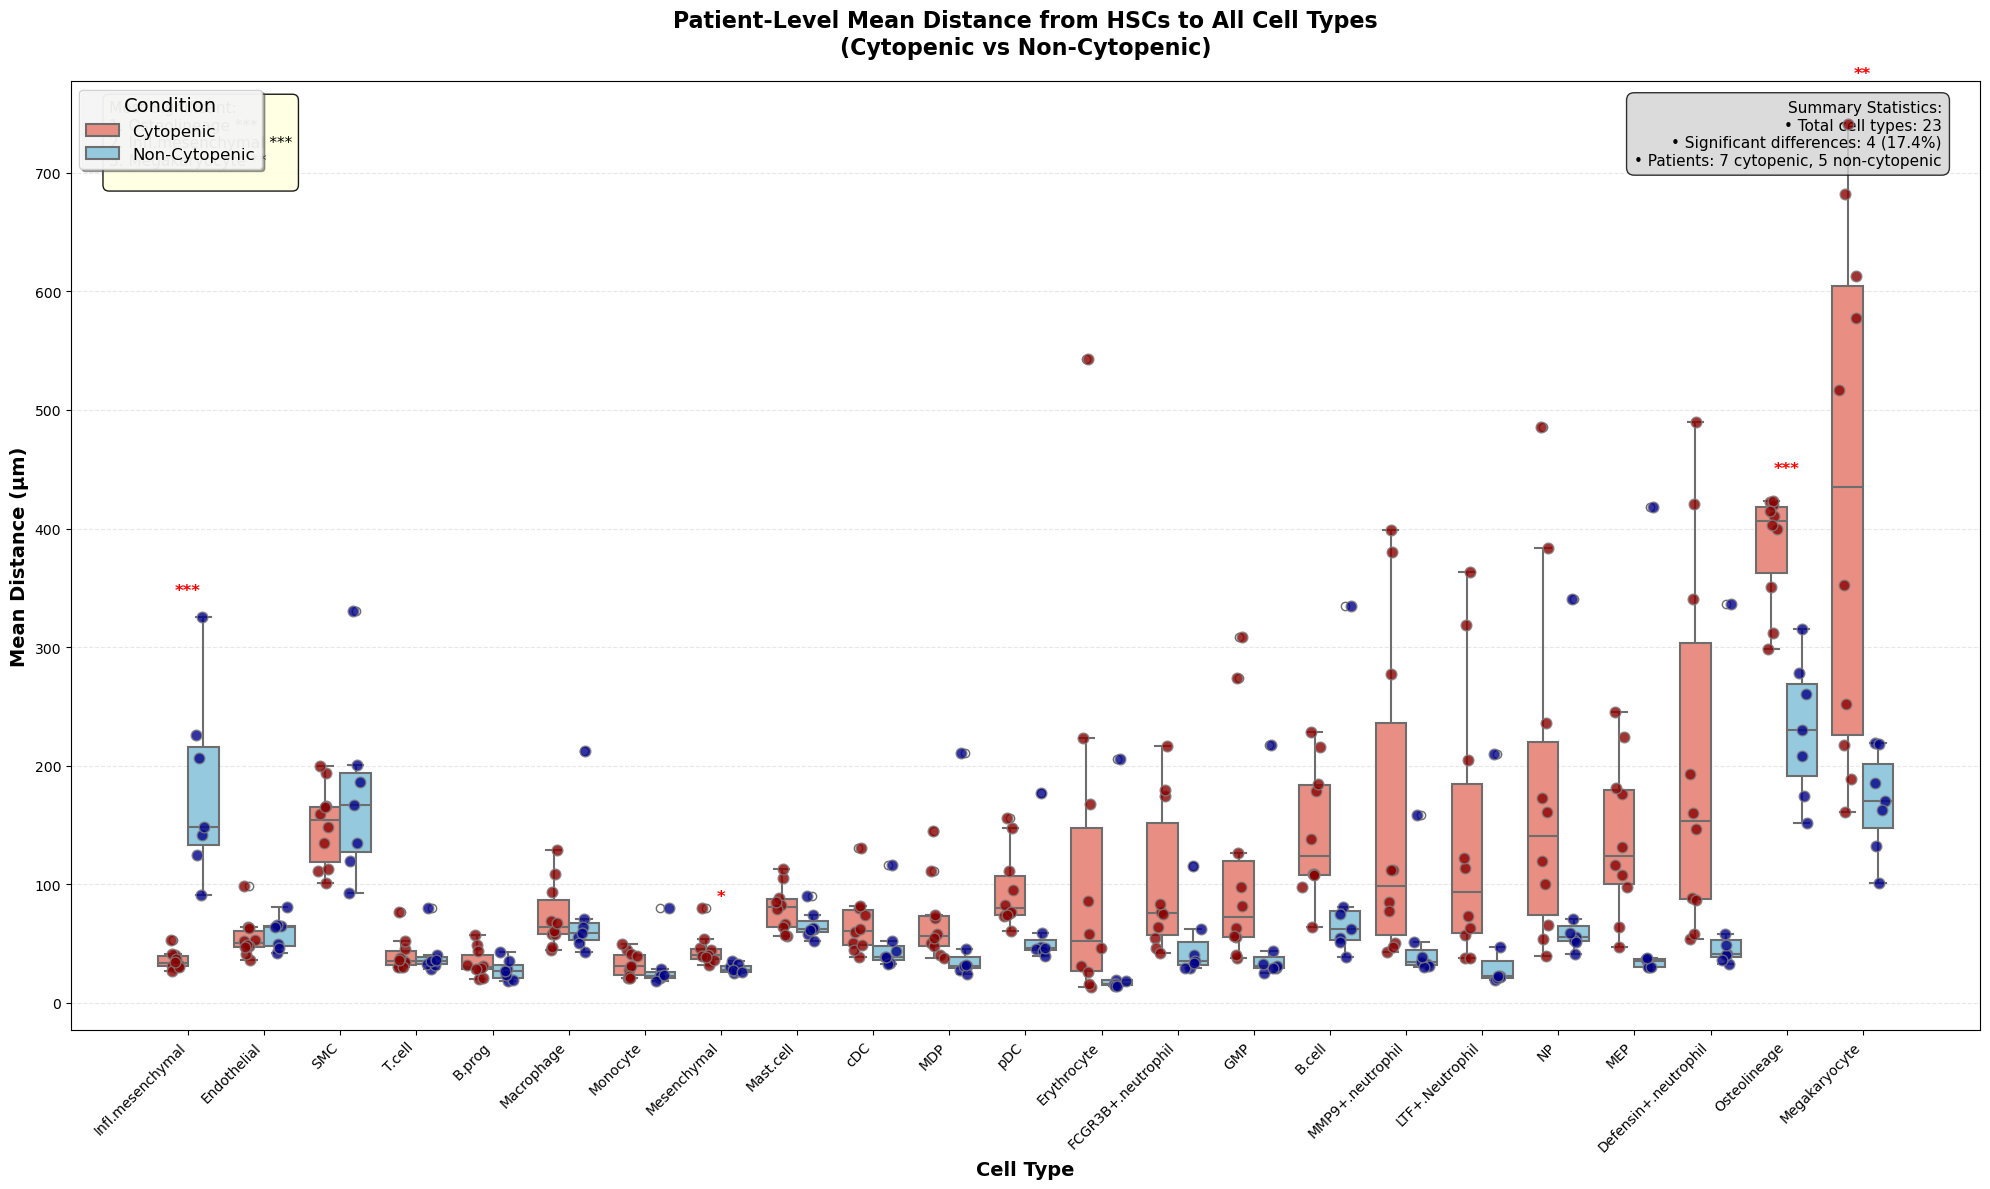

In [5]:
# Create a comprehensive plot with ALL cell types in a single figure
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.patheffects as pe

print("Creating comprehensive plot with ALL cell types...")

# Get all unique cell types from patient-level data
all_unique_cell_types = patient_level_data['Cell_Type'].unique()
n_cell_types = len(all_unique_cell_types)

print(f"Total cell types to plot: {n_cell_types}")
print("Cell types:", list(all_unique_cell_types))

# Create a large figure to accommodate all cell types
fig_width = max(20, n_cell_types * 0.8)  # Minimum 20 inches, scale with number of cell types
fig_height = 12
fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))

# Prepare data for plotting - ensure consistent ordering
patient_level_data_sorted = patient_level_data.copy()

# Sort cell types by median distance difference (cytopenic - non-cytopenic) for better visualization
cell_type_order = []
median_differences = []

for cell_type in all_unique_cell_types:
    cell_data = patient_level_data_sorted[patient_level_data_sorted['Cell_Type'] == cell_type]
    cyto_data = cell_data[cell_data['Condition'] == 'Cytopenic']['Mean_Distance']
    non_cyto_data = cell_data[cell_data['Condition'] == 'Non-Cytopenic']['Mean_Distance']
    
    if len(cyto_data) > 0 and len(non_cyto_data) > 0:
        median_diff = np.median(cyto_data) - np.median(non_cyto_data)
        median_differences.append(median_diff)
        cell_type_order.append(cell_type)

# Sort by median difference (most negative = cytopenic closer, most positive = cytopenic farther)
sorted_indices = np.argsort(median_differences)
cell_type_order = [cell_type_order[i] for i in sorted_indices]

print(f"Cell types ordered by median distance difference (cytopenic - non-cytopenic):")
for i, ct in enumerate(cell_type_order):
    print(f"  {i+1:2d}. {ct:20s} (diff: {median_differences[sorted_indices[i]]:.1f} μm)")

# Create the comprehensive box plot
sns.boxplot(data=patient_level_data_sorted, 
           x='Cell_Type', y='Mean_Distance', hue='Condition',
           order=cell_type_order,
           hue_order=['Cytopenic', 'Non-Cytopenic'],
           palette={'Cytopenic': 'salmon', 'Non-Cytopenic': 'skyblue'},
           ax=ax, width=0.8, linewidth=1.5)

# Add individual patient points with slight jitter
np.random.seed(42)
for i, cell_type in enumerate(cell_type_order):
    cell_data = patient_level_data_sorted[patient_level_data_sorted['Cell_Type'] == cell_type]
    
    # Cytopenic patients (left box)
    cyto_data = cell_data[cell_data['Condition'] == 'Cytopenic']
    if len(cyto_data) > 0:
        x_jitter = np.random.normal(i - 0.2, 0.05, len(cyto_data))
        ax.scatter(x_jitter, cyto_data['Mean_Distance'], 
                  color='darkred', s=60, alpha=0.8, zorder=10, 
                  edgecolor='grey', linewidth=1)

    # Non-cytopenic patients (right box)  
    non_cyto_data = cell_data[cell_data['Condition'] == 'Non-Cytopenic']
    if len(non_cyto_data) > 0:
        x_jitter = np.random.normal(i + 0.2, 0.05, len(non_cyto_data))
        ax.scatter(x_jitter, non_cyto_data['Mean_Distance'],
                  color='darkblue', s=60, alpha=0.8, zorder=10,
                  edgecolor='grey', linewidth=1)

# Calculate and add significance annotations
significant_pairs = []
for i, cell_type in enumerate(cell_type_order):
    cell_data = patient_level_data_sorted[patient_level_data_sorted['Cell_Type'] == cell_type]
    cyto_data = cell_data[cell_data['Condition'] == 'Cytopenic']['Mean_Distance']
    non_cyto_data = cell_data[cell_data['Condition'] == 'Non-Cytopenic']['Mean_Distance']
    
    if len(cyto_data) >= 2 and len(non_cyto_data) >= 2:
        try:
            t_stat, p_val = stats.ttest_ind(cyto_data, non_cyto_data)
            
            # Determine significance level
            if p_val < 0.001:
                sig_text = '***'
                significant_pairs.append((i, cell_type, p_val, sig_text))
            elif p_val < 0.01:
                sig_text = '**'
                significant_pairs.append((i, cell_type, p_val, sig_text))
            elif p_val < 0.05:
                sig_text = '*'
                significant_pairs.append((i, cell_type, p_val, sig_text))
            
            # Add significance annotation above the boxes
            if p_val < 0.05:
                y_max = max(max(cyto_data) if len(cyto_data) > 0 else 0,
                           max(non_cyto_data) if len(non_cyto_data) > 0 else 0)
                ax.text(i, y_max * 1.05, sig_text, ha='center', va='bottom', 
                       fontsize=12, fontweight='bold', color='red')
                
        except Exception as e:
            print(f"Statistical test failed for {cell_type}: {e}")

# Formatting
ax.set_title('Patient-Level Mean Distance from HSCs to All Cell Types\n(Cytopenic vs Non-Cytopenic)', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Mean Distance (μm)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cell Type', fontsize=14, fontweight='bold')

# Rotate x-axis labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Add grid
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Customize legend
legend = ax.legend(title='Condition', fontsize=12, title_fontsize=14, 
                  loc='upper left', frameon=True, fancybox=True, shadow=True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Add summary statistics box
n_significant = len(significant_pairs)
n_total = len(cell_type_order)
summary_text = f"""Summary Statistics:
• Total cell types: {n_total}
• Significant differences: {n_significant} ({n_significant/n_total*100:.1f}%)
• Patients: 7 cytopenic, 5 non-cytopenic"""

ax.text(0.98, 0.98, summary_text, transform=ax.transAxes, 
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.8))

# Highlight the most significant cell types
if significant_pairs:
    # Sort by p-value
    significant_pairs.sort(key=lambda x: x[2])
    top_sig = significant_pairs[:3]  # Top 3 most significant
    
    highlight_text = "Most Significant:\n"
    for i, (pos, ct, pval, sig) in enumerate(top_sig):
        highlight_text += f"{i+1}. {ct} {sig}\n"
    
    ax.text(0.02, 0.98, highlight_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

